In [ ]:
# 한국어 자연어 처리 라이브러리 설치
# 코랩 버전
# %pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 12.7 MB/s eta 0:00:00


# 의료/헬스 케어 관련 기술 보증 데이터 분석

## [미션 시나리오]

M사 : **헬스케어·바이오 분야 기술기업에 자금을 공급하는 기술금융(기술신용평가) 전문 금융기업**,
- 헬스케어 기술기업(병원/의료 IT·의료기기·디지털 헬스·바이오 등)의 헬스케어 기술금융 데이터 역량을 인정받는 회사이다.
    1. **기술 경쟁력을 평가**해
    2. **대출 승인 여부를 심사**하고
    3. 은행권과 연계해 **자금을 중개·공급**하며
    
- M사가 운용하는 데이터 체계
    - 대출을 신청한 헬스케어 기업별로
        ▶ 기술명·기술분류(헬스케어 세부분류)·자본금·설립일·기업 평가등급·신청은행·대출금액·대출 승인여부 등을 통합 수집하고,
        ▶ 기업 단위로 누적 -> 어떤 의료·바이오 기술을 가진 어떤 기업이 어떤 조건으로 심사를 받았고 그 결과 승인·부결되었는지를 한눈에 조회·분석할 수 있는 방식으로 운용된다.
        ▶ 각 기업은 재무 속성(자본금·업력)과 헬스케어 기술 속성(기술명 텍스트·의료 세부분류), 심사 속성(평가등급·승인여부)으로 정의되어 정형·비정형(기술명 텍스트) 데이터가 함께 축적된다.

<br>

- 헬스케어 기술은 연구개발 주기가 길고 인허가 리스크가 커 초기 매출과 재무 지표만으로는 상환 능력과 기술 가치를 가늠하기 어렵다.
- 유망 의료 기술기업을 선별해 자금을 공급하되 부실 위험은 낮추는 정밀한 심사 역량이 그 어느 때보다 중요해지고 있으나,
- 기업의 기술 경쟁력은 자본금·업력·평가등급 같은 정형 지표뿐 아니라 기술명에 담긴 의료·바이오 기술 내용에도 흩어져 있어 단순 재무 지표만으로는 승인 여부를 신뢰성 있게 판단하기 어렵다.
- 또한 헬스케어 **세부분류·신청은행·평가등급별**로 승인 양상과 대출 집행 규모가 크게 달라, 단일 기준의 심사만으로는 의료 기술 특성과 자금 흐름을 정확히 반영하기 어려운 상황이다.

<br>

- 헬스케어 기업의 재무·기술·심사 데이터가 텍스트 기술명과 함께 대량으로 축적되고 있어,
  - 어떤 기업 속성과 의료 기술 내용이 대출 승인을 좌우하는지를
      - 정형 분석과 텍스트 분석으로 함께 규명하고,
      - 승인 여부를 사전에 예측하는 데이터 기반 심사 보조 체계를 구축할 수 있다.
  - 다만 이를 위해서는
      1. 설립일로부터 업력을 산출하고 자본금·평가등급 등 재무·심사 지표와 승인 여부의 관계를 통계적으로 검정해야 하며,
      2. 헬스케어 기술명 텍스트를 단어 표현(임베딩)으로 분석해 '감염' 등 핵심 의료 키워드와 유사한 기술 어휘를 규명하고, 병원/의료 IT 등 세부분류별·은행별 자금 집행 구조를 파악해야 하고,
      3. 정형 변수 기반 모델과 기술명 텍스트 기반 신경망 모델을 각각 구성해 승인 예측의 신뢰도를 끌어올려야 한다.

<br>

▶ 통합된 헬스케어 기업·기술·심사 데이터를 활용해
    - **어떤 기업 속성과 의료 기술 내용**이 대출 승인을 좌우하는지,
    - **평가등급·업력·헬스케어** 세부분류에 따라 승인 양상은 어떻게 다른지,
    - 은행별 자금은 **어떤 의료 기술 분야로 흘러가는지**
<br>

  ✏️ 정형 분석과 텍스트 분석으로 규명하고,  
  ✏️ 정형 데이터 기반 승인 예측 모델과 기술명 텍스트 기반 신경망 모델을 구성  
  💡 헬스케어 기술금융 심사와 자금 배분의 신뢰도를 높이고자 한다.

### 변수 정의서

| 변수명 | 타입 | 설명 |
| -- | -- | -- |
| 회사명 | 범주 | 대출 신청 기업명 |
| 기술명 | 텍스트 | 기업 보유 기술 명칭 (특허·기술 제목 형태, 텍스트 분석·임베딩 대상) |
| 헬스케어 세부분류 | 범주 | 세부 의료 기술 분야 (병원/의료 IT·바이오·건강기능식품·의료 앱 등 115종) |
| 기술분류 | 범주 | 상위 기술 분야 (바이오 의료·정보통신·전기전자·기계 등 9종) |
| 설립일 | 문자 | 기업 설립일 (YYYY/MM/DD 문자형) |
| 신청일 | 문자 | 대출 신청 일시 (YYYY-MM-DD HH:MM:SS) |
| 평가기관 | 범주 | 기술평가 수행 기관 (기술보증기금·한국발명진흥회·KISTI 3종) |
| 평가등급 | 범주 | 기술신용 평가등급 (AAA·AA·A·BBB·T1·T3/A 등 16종) |
| 신청은행 | 범주 | 대출 신청·집행 은행 (국민·기업·우리·신한 등 15종) |
| 진행상태 | 범주 | 여신승인 / 여신거부 (목표변수 Y) |
| 대출금액 | object | 신청/집행 대출 금액 (단위: 백만원 추정, 문자·숫자 혼재) |
| 자본금 | int | 기업 자본금 |
| 설립일자 | 문자 | 설립일 (YYYY-MM-DD, 설립일과 동일 정보) |
| 설립연도 | int | 설립 연도 (업력 계산용) |
| 대출금 | int | 대출 금액 (대출금액과 동일 정보의 정수형) |
| 총합 | int | 집계 합계값  |
| 신청일자 | 문자 | 신청일 (YYYY-MM-DD, 신청일과 동일 정보) |

## [미션]

1. 대출 승인이 된 기업 중, 자본금이 가장 많은 100개 기업에 대하여 추출하고, 해당 기업의 기술명 중 가장 빈도수가 높은 단어를 확인하시오.
2. 기업의 설립일을 이용해, 기업의 업력 (설립 후 현재까지 지속된 기간 / 연도)을 계산하고, 대출 승인여부에 따른 기업 업력의 대표값의 차이가 있는지 검정하시오.
3. 기업 평가등급과 대출 승인여부의 유의미한 차이가 있는지 가설 검정을 수행하고, 대출 승인 비율을 각 평가 등급 별로 계산하시오.
4. 기술 세분류(헬스케어 세부분류)에 '병원/의료 IT'에 해당하는 기업의 기술명을 단어표현을 통해, '감염'라는 단어와 가장 유사한 단어들이 무엇이 있는지 확인하시오.
5. 대출금액을 가장 많이 집행한 은행을 확인하고, 해당 은행이 어떤 기술 세분류(헬스케어 세부분류)에 대출금액을 가장 많이 집행했는지 계산하시오.
6. 기술명과 대출금액, 기술분류, 신청은행, 자본금을 입력했을 때, 대출 승인 여부를 판별하는 모델을 Scikit Learn라이브러리를 활용해 구성하시오.
7. 기술명을 입력했을 때, 대출 승인 여부를 판별하는 모델을 구성하고자 한다. 신경망 계열의 알고리즘을 이용해 모델을 구성하고, model_loan.h5 이름으로 저장하시오.

In [4]:
import pandas as pd
import numpy as np

In [30]:
df = pd.read_excel('06_Tech_Credit_Data.xlsx')
print(df.shape)
df.head()

(2213, 17)


,회사명,기술명,헬스케어 세부분류,기술분류,설립일,신청일,평가기관,평가등급,신청은행,진행상태,대출금액,자본금,설립일자,설립연도,대출금,총합,신청일자
0,Big5시스템,"돼지 태반 추출물을 함유하는 갱년기/폐경기 장애 개선용 식품 조성물, 이를 포함하는...",건강기능식품,바이오 의료,2004/12/23,2011-03-30 00:00:00,기술보증기금,BBB,국민은행,여신승인,50,500,2004-12-23,2004,50,550,2011-03-30
1,박박사LAB항공,준연속식 초임계 추출 기술을 이용한 건강기능식품 소재,건강기능식품,바이오 의료,2000/04/19,2011-11-21 00:00:00,기술보증기금,A,국민은행,여신승인,100,940,2000-04-19,2000,100,1040,2011-11-21
2,TAX네트워크,결명자 주정추출물을 이용한 치매치료용 건강기능식품 및 의약품의 개발,건강기능식품/의약품,바이오 의료,2009/09/09,2011-02-28 00:00:00,기술보증기금,B,기업은행,여신승인,0,100,2009-09-09,2009,0,100,2011-02-28
3,코만도건설,장기 생체 나이 측정 시스템,건강측정/진단,바이오 의료,1900/01/01,2013-08-23 00:00:00,한국발명진흥회,T3/A,기업은행,여신거부,0,250,1900-01-01,1900,0,250,2013-08-23
4,윤현텍티스,수정란을 이용한 실험동물 청정 기술,바이오,바이오 의료,1994/10/04,2012-08-27 00:00:00,기술보증기금,A,우리은행,여신승인,1000,707,1994-10-04,1994,1000,1707,2012-08-27


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2213 entries, 0 to 2212
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   회사명        2213 non-null   object
 1   기술명        2213 non-null   object
 2   헬스케어 세부분류  2213 non-null   object
 3   기술분류       2213 non-null   object
 4   설립일        2213 non-null   object
 5   신청일        2213 non-null   object
 6   평가기관       2213 non-null   object
 7   평가등급       2213 non-null   object
 8   신청은행       2213 non-null   object
 9   진행상태       2213 non-null   object
 10  대출금액       2213 non-null   object
 11  자본금        2213 non-null   int64 
 12  설립일자       2213 non-null   object
 13  설립연도       2213 non-null   int64 
 14  대출금        2213 non-null   int64 
 15  총합         2213 non-null   int64 
 16  신청일자       2213 non-null   object
dtypes: int64(4), object(13)
memory usage: 294.0+ KB


In [6]:
# 1. 수치형 변수(자본금, 대출금액 등)의 진행상태별 평균, 중앙값, 최댓값, 최솟값 집계
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=== 진행상태별 수치형 변수 통계 ===")
display(df.groupby('진행상태')[numeric_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']))

# 2. 범주형 변수(평가등급, 헬스케어 세부분류, 신청은행 등)의 진행상태별 교차표 (비율 확인)
category_cols = ['평가등급', '기술분류', '신청은행', '평가기관']

for col in category_cols:
    if col in df.columns:
        print(f"\n=== 진행상태 x {col} 교차표 (건수) ===")
        ct = pd.crosstab(df[col], df['진행상태'], margins=True)
        display(ct)

        print(f"=== {col}별 승인 비율 (%) ===")
        ct_prop = pd.crosstab(df[col], df['진행상태'], normalize='index') * 100
        display(ct_prop.round(2))

=== 진행상태별 수치형 변수 통계 ===


자본금                                              설립연도               \
     count        mean median          std  min    max count         mean   
진행상태                                                                        
여신거부   405  681.839506  220.0  1622.242537    0  22314   405  2004.464198   
여신승인  1808  557.597345  250.0   884.831246 -339   9135  1808  2004.599004   

                         ...    대출금                         총합              \
      median        std  ... median        std min   max count        mean   
진행상태                     ...                                                 
여신거부  2007.0  11.849795  ...    0.0    4.96904   0   100   405  682.086420   
여신승인  2007.0  11.264596  ...   30.0  209.40970   0  5151  1808  648.021018   

                                      
     median          std  min    max  
진행상태                                  
여신거부  220.0  1622.153280    0  22314  
여신승인  334.5   921.937606 -309  10895  

[2 rows x 24 columns]


=== 진행상태 x 평가등급 교차표 (건수) ===


진행상태,여신거부,여신승인,All
평가등급,,,
A,57,255,312
AA,11,76,87
AAA,0,2,2
B,122,474,596
BB,110,483,593
BBB,95,480,575
C,1,0,1
CCC,0,2,2
T1,0,1,1


=== 평가등급별 승인 비율 (%) ===


...

진행상태,여신거부,여신승인
신청은행,,
경남은행,18.75,81.25
광주은행,20.00,80.00
국민은행,18.62,81.38
기업은행,18.24,81.76
농협,19.05,80.95
대구은행,22.22,77.78
부산은행,14.29,85.71
스탠다드차타드,25.00,75.00
신한은행,17.68,82.32



=== 진행상태 x 평가기관 교차표 (건수) ===


진행상태,여신거부,여신승인,All
평가기관,,,
기술보증기금,400,1795,2195
한국과학기술정보연구원,0,2,2
한국발명진흥회,5,11,16
All,405,1808,2213


=== 평가기관별 승인 비율 (%) ===


진행상태,여신거부,여신승인
평가기관,,
기술보증기금,18.22,81.78
한국과학기술정보연구원,0.00,100.00
한국발명진흥회,31.25,68.75


In [11]:
# %pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.9 MB/s eta 0:00:00


In [13]:
from konlpy.tag import Okt
okt = Okt()

### 1. 대출 승인이 된 기업 중,

- 자본금이 가장 많은 100개 기업에 대하여 추출하고,
- 해당 기업의 기술명 중 가장 빈도수가 높은 단어를 확인


In [31]:
# 1. 대출 승인 기업 중 자본금 상위 100개 추출
print(df['자본금'].dtype)   # 정수형(int64)
top100_approved = (
    df[df['진행상태'] == '여신승인']
    .sort_values(by='자본금', ascending=False)
    .head(100)
)
top100_approved

int64


,회사명,기술명,헬스케어 세부분류,기술분류,설립일,신청일,평가기관,평가등급,신청은행,진행상태,대출금액,자본금,설립일자,설립연도,대출금,총합,신청일자
970,매너상훈텍티스,인공 와우 정밀 절삭 가공 기술 설계 및 제조,임플란트/의료소재,소재(재료금속),2000/12/21,2012-08-14 11:29:57,기술보증기금,BBB,국민은행,여신승인,30,9135,2000-12-21,2000,30,9165,2012-08-14
1717,코만도화학,고정밀 투석용 필터 개발,감염관리/의료소모품,기계,2004/09/09,2012-10-26 11:44:10,기술보증기금,B,기업은행,여신승인,100,7633,2004-09-09,2004,100,7733,2012-10-26
2037,다영텍티스,CT 영상 기반 간질환 멀티모달 융합 진단 모델,의료영상 AI,바이오 의료,2007/01/28,2011-12-06 16:36:35,기술보증기금,BB,우리은행,여신승인,100,6864,2007-01-28,2007,100,6964,2011-12-06
1035,경주파트너즈,AI 기반 만성질환 통합관리 플랫폼 상용화 기술,디지털치료제/모바일헬스,정보통신,1994/06/08,2012-07-24 12:58:53,기술보증기금,BB,기업은행,여신승인,30,6653,1994-06-08,1994,30,6683,2012-07-24
680,미니마니모그룹,디지털 X선 촬영장치용 자동 노출 제어 고도화,의료영상 장치,전기전자,2011/11/12,2012-10-02 10:27:19,기술보증기금,BB,기업은행,여신승인,50,6557,2011-11-12,2011,50,6607,2012-10-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1140,사기사텍티스,클라우드 전환을 적용한 처방전달시스템(OCS) 양산 기술,병원/의료 IT,정보통신,2005/01/09,2012-07-27 09:03:06,기술보증기금,BBB,기업은행,여신승인,100,2067,2005-01-09,2005,100,2167,2012-07-27
230,바운디건설,콘드로이친을 이용한 기억력 개선 건강기능식품 소재 개발 및 임상 적용,건강기능식품,바이오 의료,2009/10/07,2012-04-26 11:49:08,기술보증기금,BB,아이디어브릿지자산운용사,여신승인,30,2057,2009-10-07,2009,30,2087,2012-04-26
1598,ONE시스템,실시간 유전자증폭(real-time PCR) 기반 호흡기바이러스 8종 진단 키트 개발,체외진단,바이오 의료,2003/11/22,2013-07-06 15:13:14,기술보증기금,A,우리은행,여신승인,30,2045,2003-11-22,2003,30,2075,2013-07-06
1194,비모수네트워크,궤양성 대장염 치료제용 서방형 미립구 제제 상용화 기술,제형/약물전달,화학(화공 섬유),2009/08/08,2013-02-19 14:16:47,기술보증기금,BB,기업은행,여신승인,30,2044,2009-08-08,2009,30,2074,2013-02-19


In [32]:
# 2. Okt 명사 추출 (2글자 이상만: '용','물' 같은 한 글자 명사는 의미가 약함)
nouns_list = []
for text in top100_approved['기술명']:
    nouns_list.extend([n for n in okt.nouns(str(text)) if len(n) > 1])
nouns_list

['인공',
 '와우',
 '정밀',
 '절삭',
 '가공',
 '기술',
 '설계',
 '제조',
 '정밀',
 '투석',
 '필터',
 '개발',
 '영상',
 '기반',
 '간질',
 '멀티',
 '융합',
 '진단',
 '모델',
 '기반',
 '만성',
 '질환',
 '통합',
 '관리',
 '플랫폼',
 '상용',
 '기술',
 '디지털',
 '촬영장',
 '자동',
 '노출',
 '제어',
 '고도화',
 '내시경',
 '자동',
 '노출',
 '제어',
 '상용',
 '기술',
 '침습',
 '가축',
 '질병',
 '조기',
 '경보',
 '시스템',
 '국산',
 '개발',
 '정밀',
 '무균',
 '충전',
 '공정',
 '설계',
 '제조',
 '치과',
 '임플란트',
 '파킨슨병',
 '치료',
 '리포좀',
 '약물',
 '전달',
 '국산',
 '개발',
 '오리고기',
 '이용',
 '사용',
 '멸균',
 '레토르트',
 '제품',
 '개발',
 '발성',
 '섬유',
 '치료',
 '개량',
 '신약',
 '상용',
 '기술',
 '침습',
 '일회용',
 '배양',
 '시스템',
 '설계',
 '제조',
 '돼지',
 '가금',
 '혈청',
 '진단',
 '기술',
 '클로렐라',
 '이용',
 '혈중',
 '중성',
 '지질',
 '개선',
 '건강',
 '기능',
 '식품',
 '소재',
 '플랫폼',
 '개발',
 '클라우드',
 '기반',
 '호흡',
 '재활',
 '프로그램',
 '국산',
 '개발',
 '휴대',
 '정밀',
 '수액',
 '세트',
 '제조',
 '기술',
 '스피루리나',
 '이용',
 '관절',
 '연골',
 '건강',
 '건강',
 '기능',
 '식품',
 '소재',
 '양산',
 '기술',
 '실시간',
 '대시보드',
 '적용',
 '의료',
 '마이',
 '데이터',
 '플랫폼',
 '상용',
 '기술',
 '기반',
 '만성',
 '통증',
 '관리',
 '디지털',
 '치료',
 

In [33]:
# 3. 전체 빈도 (상위 15개까지 확인)
word_counts = pd.Series(nouns_list).value_counts()
print("=== 전체 명사 빈도 상위 15 ===")
display(word_counts.head(15))

=== 전체 명사 빈도 상위 15 ===


,count
개발,36
기술,30
기능,21
건강,20
제조,20
기반,20
치료,19
이용,18
설계,14
식품,13


In [22]:
# 주요 세부분류 20개
top20_fields = df['헬스케어 세부분류'].value_counts().head(20)
top20_fields

,count
헬스케어 세부분류,
의료영상 AI,284
건강기능식품,226
병원/의료 IT,183
신약/바이오의약품,182
의료영상 장치,149
생체계측/모니터링,110
바이오 소재/시약,106
제형/약물전달,104
감염관리/의료소모품,91


In [36]:
top20_fields = df['헬스케어 세부분류'].value_counts().head(20).index

word_field_count = {}
for field in top20_fields:
    field_words = set()            # 한 분야 안에서는 한 번만 세기
    for text in df[df['헬스케어 세부분류'] == field]['기술명']:
        field_words.update([n for n in okt.nouns(text) if len(n) > 1])
    for w in field_words:
        word_field_count[w] = word_field_count.get(w, 0) + 1

field_spread = pd.Series(word_field_count).sort_values(ascending=False)

stopwords = list(field_spread[field_spread >= 15].index)
stopwords = stopwords + ['이용', '기반']   # '~을 이용한', '~기반' 같은 연결 표현

In [37]:
# 범용어 집계 결과
stopwords

['기술',
 '제조',
 '개발',
 '국산',
 '고도화',
 '설계',
 '적용',
 '사업',
 '플랫폼',
 '양산',
 '상용',
 '이용',
 '기반']

In [38]:
word_counts_sw = pd.Series([n for n in nouns_list if n not in stopwords]).value_counts()
print("=== 범용어 제외 상위 15 ===")
display(word_counts_sw.head(15))

=== 범용어 제외 상위 15 ===


,count
기능,21
건강,20
치료,19
소재,13
식품,13
진단,12
영상,11
정밀,9
기기,8
휴대,7


#### 범용어 제외 후 명사 중 최빈 단어 : '기능'(21) · '건강'(20) · '치료'(19)

- '개발'(36회)이 최빈 단어였으나 '개발·기술·제조' 등은 주요 세부분류 20개 중 15개 이상 분야에 두루 나오는 범용어라 불용어로 제외
- '건강·기능'은 '건강기능식품'에서 나뉜 단어로 자본금이 큰 승인 기업은 건강기능식품, 치료, 소재, 진단 관련 기술이 중심

### 2. 기업의 설립일을 이용해,

- 기업의 업력(설립 후 현재까지 지속된 기간 / 연도)을 계산하고,
- 대출 승인여부에 따른 기업 업력의 대표값의 차이가 있는지 검정


In [39]:
# 1. 설립일 이상치 확인
# 1900-01-01인 기업이 20개 -> '설립일 모름' 으로 처리하여 제외

print('설립연도 1900 개수:', (df['설립연도'] == 1900).sum())
df2 = df[df['설립연도'] != 1900].copy()     # .copy(): 원본 df를 건드리지 않도록 복사본 사

설립연도 1900 개수: 20


In [40]:
# 2. 업력 계산 (현재 연도 - 설립연도)
from datetime import datetime

this_year = datetime.now().year             # 현재 연도(2026)
df2['업력'] = this_year - df2['설립연도']

# 승인/거부 그룹별 업력 요약 (개수, 평균, 표준편차, 최소, 사분위수, 최대)
df2.groupby('진행상태')['업력'].describe()

,count,mean,std,min,25%,50%,75%,max
진행상태,,,,,,,,
여신거부,401.0,20.493766,5.621885,13.0,16.0,19.0,24.0,40.0
여신승인,1792.0,20.467076,5.423137,13.0,16.0,19.0,24.0,44.0


In [41]:
from scipy import stats

approve = df2[df2['진행상태'] == '여신승인']['업력']
reject = df2[df2['진행상태'] == '여신거부']['업력']

# 3. 정규성 검정 (Shapiro-Wilk)
print('정규성 - 승인:', stats.shapiro(approve).pvalue)
print('정규성 - 거부:', stats.shapiro(reject).pvalue)

정규성 - 승인: 2.6485962009543185e-30
정규성 - 거부: 8.314234733008606e-15


**p < 0.05 : 귀무가설 기각 → 정규분포가 아님**

- 2.6 ~ e-30 = 0.000…00026
- 8.3 ~ e-15 = 0.0000000000000083

In [42]:
# 4. Mann-Whitney U 검정 (비모수 검정)
#   귀무가설: 승인 기업과 거부 기업의 업력에 차이가 없다
#   대립가설: 승인 기업과 거부 기업의 업력에 차이가 있다
print('승인 중앙값:', approve.median(), '/ 거부 중앙값:', reject.median())
print(stats.mannwhitneyu(approve, reject))

# 5. t-검정 - 평균 비교
print('승인 평균:', round(approve.mean(), 2), '/ 거부 평균:', round(reject.mean(), 2))
print(stats.ttest_ind(approve, reject))

승인 중앙값: 19.0 / 거부 중앙값: 19.0
MannwhitneyuResult(statistic=np.float64(361598.0), pvalue=np.float64(0.8404532960578897))
승인 평균: 20.47 / 거부 평균: 20.49
TtestResult(statistic=np.float64(-0.0884862687865131), pvalue=np.float64(0.9294982842293344), df=np.float64(2191.0))


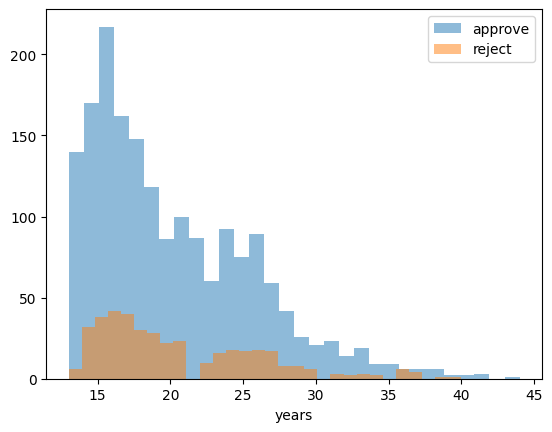

In [43]:
# 업력 분포를 그래프로 확인 (정규분포라면 좌우 대칭 종 모양)
import matplotlib.pyplot as plt

plt.hist(approve, bins=30, alpha=0.5, label='approve')
plt.hist(reject, bins=30, alpha=0.5, label='reject')
plt.xlabel('years')
plt.legend()
plt.show()

- 설립연도가 1900인 20개 기업은 결측으로 보고 제외

- 두 그룹 모두 정규성 검정에서 p < 0.05가 나와 정규분포가 아님
- 비모수 검정인 Mann-Whitney U 검정을 사용
    - 검정 결과 p = 0.84 > 0.05라 귀무가설을 기각하지 못함
    - t-검정(p = 0.93)도 결론이 같음

- **결론** : 대출 승인 기업과 거부 기업의 업력 중앙값(19년 vs 19년)에는 유의미한 차이가 없음. 이 데이터에서 업력은 승인 여부를 가르는 요인이 아님.

### 3. 평가등급과 대출 승인 여부의 관계 검정

+ 대출 승인 비율을 각 평가 등급 별로 계산


In [44]:
# 1. 교차표 만들기 - 행: 평가등급 / 열: 진행상태(여신거부, 여신승인)
grade_table = pd.crosstab(df['평가등급'], df['진행상태'])

# 2. 등급별 승인 비율 = 승인 수 / (거부 수 + 승인 수)
grade_table['합계'] = grade_table['여신거부'] + grade_table['여신승인']
grade_table['승인비율'] = (grade_table['여신승인'] / grade_table['합계']).round(3)

grade_table.sort_values('합계', ascending=False)

진행상태,여신거부,여신승인,합계,승인비율
평가등급,,,,
B,122,474,596,0.795
BB,110,483,593,0.815
BBB,95,480,575,0.835
A,57,255,312,0.817
AA,11,76,87,0.874
T3/A,3,15,18,0.833
T2/AA,1,9,10,0.900
T4/BBB,3,5,8,0.625
T8/CC,2,1,3,0.333


In [45]:
# 3. 카이제곱 검정에 쓸 등급 고르기 ('기대빈도'가 5 이상)
#  → 건수가 충분한 주요 5개 등급(AA, A, BBB, BB, B)만 사용 (이 5개가 전체 2,213건 중 2,163건 = 97.7%)

main_grades = ['AA', 'A', 'BBB', 'BB', 'B']

df3 = df[df['평가등급'].isin(main_grades)]      # isin: 목록에 있는 등급만 남기기
print('검정에 사용한 데이터:', len(df3), '/ 전체:', len(df))

table = pd.crosstab(df3['평가등급'], df3['진행상태'])
table = table.loc[main_grades]                  # 높은 등급 → 낮은 등급 순서로 정렬
table['승인비율'] = (table['여신승인'] / (table['여신거부'] + table['여신승인'])).round(3)
table

검정에 사용한 데이터: 2163 / 전체: 2213


진행상태,여신거부,여신승인,승인비율
평가등급,,,
AA,11,76,0.874
A,57,255,0.817
BBB,95,480,0.835
BB,110,483,0.815
B,122,474,0.795


In [46]:
# 4. 카이제곱 독립성 검정
#    두 범주형 변수(평가등급, 승인여부)가 서로 관계가 있는지
#    - 귀무가설: 평가등급과 대출 승인 여부는 관계가 없다(독립이다)
#    - 대립가설: 평가등급에 따라 대출 승인 여부가 달라진다

chi2, p, dof, expected = stats.chi2_contingency(table[['여신거부', '여신승인']])
print('카이제곱 통계량:', round(chi2, 3))
print('p-value:', round(p, 4))
print('자유도:', dof)                              # (행 5개 - 1) × (열 2개 - 1) = 4

# 기대빈도가 모두 5 이상인지 확인 (검정 조건)
print('기대빈도 최솟값:', round(expected.min(), 1))

카이제곱 통계량: 4.986
p-value: 0.2888
자유도: 4
기대빈도 최솟값: 15.9


- 등급별 승인 비율
    - AA 87.4%, A 81.7%, BBB 83.5%, BB 81.5%, B 79.5%

- p = 0.289 > 0.05라 귀무가설을 기각하지 못함.(독립이다)

- **결론** : 평가등급과 대출 승인 여부 사이에는 통계적으로 유의미한 관계가 없음.

### 4. 기술 세분류(헬스케어 세부분류)에

- '병원/의료 IT'에 해당하는 기업의 기술명을 단어표현을 통해,   
  **'감염'라는 단어와 가장 유사한 단어**들이 무엇이 있는지 확인


In [47]:
# Word2Vec → '감염'과 유사한 단어 찾기

# 1. 헬스케어 세부분류가 '병원/의료 IT'인 기업만 추출
it_df = df[df['헬스케어 세부분류'] == '병원/의료 IT']
print('기업 수:', len(it_df))


# 2. Word2Vec 입력 데이터 만들기
#  → 기술명 하나를 문장 하나로 보고, Okt로 명사만 뽑아 리스트로 만들기
sentences = []
for text in it_df['기술명']:
    nouns = okt.nouns(text)
    sentences.append([n for n in nouns if len(n) > 1])   # 2글자 이상 명사만

# 영어로만 된 기술명은 Okt가 명사를 뽑지 못해 빈 리스트가 됨
print(sentences[:5])
print('빈 리스트 개수:', sum(1 for s in sentences if len(s) == 0))

기업 수: 183
[[], ['의료', '기관', '전용', '고객', '관리', '솔루션'], [], ['게이트웨이', '기반', '통합', '적용', '전자', '의무', '기록', '국산', '개발'], ['표준', '연동', '적용', '간호', '정보', '시스템', '상용', '기술']]
빈 리스트 개수: 2


In [48]:
# 3. '감염'이 들어간 기술명 확인
print('감염 등장 횟수:', sum(s.count('감염') for s in sentences))
it_df[it_df['기술명'].str.contains('감염')]['기술명']

감염 등장 횟수: 9


,기술명
265,실시간 대시보드를 적용한 감염관리 모니터링 시스템 개발 및 임상 적용
328,블록체인 기반 이력관리를 적용한 감염관리 모니터링 시스템 플랫폼 개발
362,클라우드 전환을 적용한 감염관리 모니터링 시스템 개발 및 임상 적용
451,API 게이트웨이 기반 통합을 적용한 감염관리 모니터링 시스템 플랫폼 개발
890,음성인식 기록 자동화를 적용한 감염관리 모니터링 시스템 양산 기술
1222,다기관 데이터 연계를 적용한 감염관리 모니터링 시스템 상용화 기술
1781,HL7 FHIR 표준 연동을 적용한 감염관리 모니터링 시스템 개발
1853,모바일 앱 연동을 적용한 감염관리 모니터링 시스템 설계 및 제조
2003,AI 자동 코딩을 적용한 감염관리 모니터링 시스템 개발 및 임상 적용


In [50]:
# !pip install gensim konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.6 MB/s eta 0:00:00


In [51]:
# 4. Word2Vec 학습 - Skip-Gram 방식
#    Skip-Gram (sg=1): 중심 단어로 주변 단어를 예측하며 학습 → 데이터가 적고 드물게 나오는 단어에 유리

from gensim.models import Word2Vec

model_sg = Word2Vec(sentences, vector_size=100, window=3, min_count=1,
                    sg=1, epochs=200, seed=42, workers=1)

# most_similar: 코사인 유사도가 높은(벡터 방향이 비슷한) 단어 순으로 반환
print("=== Skip-Gram: '감염'과 유사한 단어 ===")
for word, score in model_sg.wv.most_similar('감염', topn=10):
    print(word, round(score, 3))

=== Skip-Gram: '감염'과 유사한 단어 ===
모니터링 0.76
스마트 0.554
솔루션 0.542
수술실 0.532
병상 0.492
스케줄링 0.487
고객 0.469
원가 0.46
위치 0.459
전용 0.455


In [52]:
# 5. Word2Vec 학습 - CBOW 방식 (비교용)
#    CBOW (sg=0): 주변 단어들로 중심 단어를 예측하며 학습 → 자주 나오는 단어 위주로 학습됨

model_cbow = Word2Vec(sentences, vector_size=100, window=3, min_count=1,
                      sg=0, epochs=200, seed=42, workers=1)

print("=== CBOW: '감염'과 유사한 단어 ===")
for word, score in model_cbow.wv.most_similar('감염', topn=10):
    print(word, round(score, 3))

=== CBOW: '감염'과 유사한 단어 ===
모니터링 0.758
관리 0.657
솔루션 0.573
적용 0.56
고객 0.548
전용 0.536
체인 0.524
시스템 0.516
병원 0.496
스케줄링 0.493


In [53]:
# 6. 유사어로 나온 단어가 실제로 어떤 기술명에 쓰였는지 확인
for word in ['수술실', '병상']:
    print(f'[{word}]')
    print(it_df[it_df['기술명'].str.contains(word)]['기술명'].head(3).tolist())

[수술실]
['API 게이트웨이 기반 통합을 적용한 수술실 스케줄링 시스템 설계 및 제조', '음성인식 기록 자동화를 적용한 수술실 스케줄링 시스템 제조 기술', '실시간 대시보드를 적용한 수술실 스케줄링 시스템 개발 및 사업화']
[병상]
['모바일 앱 연동을 적용한 스마트 병상 관리 시스템 상용화 기술', '개인정보 비식별화 처리를 적용한 스마트 병상 관리 시스템 개발 및 사업화', '클라우드 전환을 적용한 스마트 병상 관리 시스템 상용화 기술']


- '감염'과 가장 유사한 단어는 **모니터링**입니다.
  - '감염'이 나오는 9개 기술명에 모두 '감염관리 모니터링'으로 함께 쓰임
- 그다음은 수술실, 병상, 스케줄링, 솔루션
  - 수술실 스케줄링 시스템, 스마트 병상 관리 시스템처럼 '감염'과 같은 자리에 들어가는 단어라서, 병원에서 관리하는 대상이라는 점에서 비슷한 의미로 학습됨.
- CBOW는 '관리, 적용, 시스템'처럼 자주 나오는 일반 단어가 섞여 나옴.


### 5. 대출금액을 가장 많이 집행한 은행을 확인하고,

- 해당 은행이 어떤 기술 세분류(헬스케어 세부분류)에 대출금액을 가장 많이 집행했는지 계산


In [54]:
# 1. 어떤 금액 컬럼을 쓸지 확인
print(df['대출금액'].unique()[:10])     # 문자 '금액없음'이 섞여 있는지 확인
print(df['대출금'].dtype)               # int64 → 바로 합산 가능

# 2. 은행별 대출금 합계 ('집행'된 금액이므로 대출이 승인된 건만 사용)
#    groupby('신청은행')['대출금'].sum() : 은행별로 대출금을 더함
approved_df = df[df['진행상태'] == '여신승인']
bank_sum = approved_df.groupby('신청은행')['대출금'].sum().sort_values(ascending=False)
bank_sum

[50 100 0 1000 30 500 1500 130 40 200]
int64


,대출금
신청은행,
기업은행,84285
국민은행,26524
우리은행,25425
신한은행,13572
대구은행,2890
하나은행,2460
경남은행,1710
농협,1330
부산은행,1150


In [55]:
# 3. 1위 은행과 전체 대비 비중
top_bank = bank_sum.index[0]
print('대출금액을 가장 많이 집행한 은행:', top_bank)
print('집행 금액:', bank_sum.iloc[0])
print('전체 대비 비중:', round(bank_sum.iloc[0] / bank_sum.sum() * 100, 1), '%')

대출금액을 가장 많이 집행한 은행: 기업은행
집행 금액: 84285
전체 대비 비중: 51.6 %


In [56]:
# 4. 1위 은행의 헬스케어 세부분류별 대출금 합계
#    agg(['sum', 'count']) : 합계와 건수를 한 번에 계산 → 금액이 많은 이유가 '건수가 많아서'인지 '한 건이 커서'인지

bank_df = approved_df[approved_df['신청은행'] == top_bank]
bank_sub = (bank_df.groupby('헬스케어 세부분류')['대출금']
            .agg(['sum', 'count'])
            .sort_values('sum', ascending=False))

# 1위 은행 안에서의 비중(%)
bank_sub['비중(%)'] = (bank_sub['sum'] / bank_sub['sum'].sum() * 100).round(1)
bank_sub.head(10)

,sum,count,비중(%)
헬스케어 세부분류,,,
의료영상 AI,7704,117,9.1
건강기능식품,7370,97,8.7
의료영상 장치,7310,55,8.7
병원/의료 IT,6470,78,7.7
수술/중재기기,6100,36,7.2
의료기기(치과),5271,5,6.3
신약/바이오의약품,4690,75,5.6
제형/약물전달,3620,48,4.3
의료기기 부품/제조,3520,24,4.2


- 대출금액을 가장 많이 집행한 은행은
    - 1위 - 기업은행(84,285, 전체의 51.6%)
    - 2위 - 국민은행(26,524)

- 기업은행이 가장 많이 집행한 세부분류
    1. 의료영상 AI(7,704, 117건, 9.1%)
    2. 건강기능식품(7,370,  97건, 8.7%)
    3. 의료영상 장치(7,310, 55건, 8.7%)
    
  - 기업은행은 특정 분야에 몰지 않고 여러 헬스케어 분야에 고르게 집행 증

- 참고 : 분야마다 집행 방식이 다름
    - 의료영상 AI는 117건에 평균 약 66으로 작은 금액을 여러 건에 나눠 집행
    - 의료기기(치과)는 5건에 평균 약 1,054로 적은 기업에 큰 금액을 집행

### 6. 기술명과 대출금액, 기술분류, 신청은행, 자본금을 입력했을 때,

- **대출 승인 여부를 판별**하는 모델을 **Scikit Learn**라이브러리를 활용해 구성


In [57]:
# 기술명(텍스트)       → TF-IDF 로 숫자 변환
# 기술분류, 신청은행(범주) → 원-핫 인코딩
# 대출금액, 자본금(숫자)   → 그대로 사용

# 1. '여신승인' : 승인 = 1, 거부 = 0
df['승인'] = (df['진행상태'] == '여신승인').astype(int)

# 2. 대출금액 정리 - '금액없음' 0으로 변환
df['대출금액_숫자'] = pd.to_numeric(df['대출금액'], errors='coerce').fillna(0)  # .to_numeric(errors='coerce') : 숫자로 못 바꾸는 값은 NaN 처

# 3. 기술명 → 명사만 공백으로 이은 문장으로 변환 (TF-IDF 입력용)
df['기술명_명사'] = [' '.join([n for n in okt.nouns(t) if len(n) > 1]) for t in df['기술명']]
df[['기술명', '기술명_명사']].head()

,기술명,기술명_명사
0,"돼지 태반 추출물을 함유하는 갱년기/폐경기 장애 개선용 식품 조성물, 이를 포함하는...",돼지 태반 추출 함유 갱년기 폐경기 장애 개선 식품 조성 포함 건강 기능 식품 제조 방법
1,준연속식 초임계 추출 기술을 이용한 건강기능식품 소재,연속 초임 추출 기술 이용 건강 기능 식품 소재
2,결명자 주정추출물을 이용한 치매치료용 건강기능식품 및 의약품의 개발,결명자 주정 추출 이용 치매 치료 건강 기능 식품 의약품 개발
3,장기 생체 나이 측정 시스템,장기 생체 나이 측정 시스템
4,수정란을 이용한 실험동물 청정 기술,수정란 이용 실험동물 청정 기술


In [58]:
# 4. 범주형 → 원-핫 인코딩, 숫자형은 그대로
etc = pd.get_dummies(df[['기술분류', '신청은행']]).astype(int)  # get_dummies : 범주형 0/1
etc['대출금액'] = df['대출금액_숫자']
etc['자본금'] = df['자본금']
print(etc.shape)
etc.head()

(2213, 26)


,기술분류_기계,"기술분류_기타(게임,콘텐츠, 디자인)","기술분류_기타(콘텐츠, 디자인)",기술분류_바이오 의료,기술분류_소재(재료금속),기술분류_전기전자,기술분류_정보통신,기술분류_화학(화공 섬유),기술분류_환경,신청은행_경남은행,...,신청은행_스탠다드차타드,신청은행_신한은행,신청은행_아이디어브릿지자산운용사,신청은행_외환은행,신청은행_우리은행,신청은행_전북은행,신청은행_하나은행,신청은행_한국수출입은행,대출금액,자본금
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,50.0,500
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,100.0,940
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,100
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,250
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1000.0,707


##### 기술분류 9개 + 신청은행 15개 + 숫자 2개

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 5. 학습용 / 평가용 나누기
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df['승인'], random_state=42)


# 6. TF-IDF: 기술명을 숫자 벡터로 변환 (단어 빈도(TF) × 희귀할수록 커지는 가중치(IDF))
tfidf = TfidfVectorizer(max_features=300)
train_text = tfidf.fit_transform(df.loc[train_idx, '기술명_명사']).toarray()
test_text = tfidf.transform(df.loc[test_idx, '기술명_명사']).toarray()

# 7. 텍스트 특성(300개) + 나머지 특성(26개) 옆으로 합치기
X_train = np.hstack([train_text, etc.loc[train_idx].values])    # np.hstack : 배열을 가로로 이어 붙임
X_test = np.hstack([test_text, etc.loc[test_idx].values])
y_train = df.loc[train_idx, '승인']
y_test = df.loc[test_idx, '승인']
print(X_train.shape, X_test.shape)

(1770, 326) (443, 326)


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 8. 랜덤포레스트 모델 학습
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42) # class_weight='balanced' : 거부(18%)가 적어서, 거부를 틀렸을 때 벌점을 더 크게
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

# 9. 평가
#    confusion_matrix : [[거부를 거부로, 거부를 승인으로],[승인을 거부로, 승인을 승인으로]]
print('정확도:', round(accuracy_score(y_test, pred), 3))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['여신거부', '여신승인']))

정확도: 0.986
[[ 80   1]
 [  5 357]]
              precision    recall  f1-score   support

        여신거부       0.94      0.99      0.96        81
        여신승인       1.00      0.99      0.99       362

    accuracy                           0.99       443
   macro avg       0.97      0.99      0.98       443
weighted avg       0.99      0.99      0.99       443



In [61]:
# 10. 변수 중요도
feature_names = list(tfidf.get_feature_names_out()) + list(etc.columns)
importance = pd.Series(rf.feature_importances_, index=feature_names)    # feature_importances_ 합계 = 1, 클수록 중요
importance.sort_values(ascending=False).head(10)

,0
대출금액,0.668485
자본금,0.023193
개발,0.012142
기술,0.007672
기반,0.006200
플랫폼,0.006149
제조,0.005978
적용,0.005828
치료,0.005776
사업,0.005115


In [62]:
# 11. 대출금액과 승인 여부 직접 비교 (성능이 너무 높고 대출금액 중요도가 압도적)
#     대출금액이 0인지 × 진행상태 교차표
pd.crosstab(df['대출금액_숫자'] == 0, df['진행상태'])

진행상태,여신거부,여신승인
대출금액_숫자,,
False,1,1764
True,404,44


In [63]:
# 12. 대출금액을 빼고 다시 학습 (기술명, 기술분류, 신청은행, 자본금만)
#     대출금액은 '승인된 뒤 정해지는 금액'이라 심사 전에는 알 수 없는 정보 → 이 변수 없이도 예측이 되는지 확인

X_train2 = np.hstack([train_text, etc.drop(columns='대출금액').loc[train_idx].values])
X_test2 = np.hstack([test_text, etc.drop(columns='대출금액').loc[test_idx].values])

rf2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf2.fit(X_train2, y_train)
pred2 = rf2.predict(X_test2)

print('정확도:', round(accuracy_score(y_test, pred2), 3))
print(confusion_matrix(y_test, pred2))
print(classification_report(y_test, pred2, target_names=['여신거부', '여신승인']))

정확도: 0.808
[[  0  81]
 [  4 358]]
              precision    recall  f1-score   support

        여신거부       0.00      0.00      0.00        81
        여신승인       0.82      0.99      0.89       362

    accuracy                           0.81       443
   macro avg       0.41      0.49      0.45       443
weighted avg       0.67      0.81      0.73       443



|  | 5개 변수 모두 | 대출금액 제외 |
| -- | -- | -- |
| 정확도 | 0.986 | 0.810 |
| 혼동행렬 | [[80, 1], [5, 357]] | [[0, 81], [4, 358]] |
| 거부 재현율 | 0.99 | 0.00 |

- 대출금액을 빼고 학습하면 정확도는 81%지만, 거부 81건을 하나도 맞히지 못함(거부 재현율 0%).
    - 모델이 거의 모든 기업을 승인으로 예측.
    - 전부 승인으로 찍기만 해도 정확도가 81.7%이므로, 이 모델은 아무 정보도 학습하지 못했다고 볼 수 있음

- 기술명·기술분류·신청은행·자본금만으로는 승인 여부를 예측할 수 없고,  
  앞의 98.6%는 대출금액(심사 결과로 정해지는 값) 덕분

### 7. 기술명을 입력했을 때, 대출 승인 여부를 판별하는 모델을 구성

- 신경망 계열의 알고리즘을 이용해 모델을 구성하고,
- model_loan.h5 이름으로 저장

In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [66]:
# 순서 : 텍스트 → 정수 시퀀스(Text to Sequence) → 길이 맞추기(Padding) → Embedding + LSTM 신경망 → model_loan.h5 저장

# 1. 6번에서 나눈 학습/평가 데이터를 그대로 사용
# '기술명_명사' : 6번에서 만든 '명사만 공백으로 이은 기술명'
train_texts = df.loc[train_idx, '기술명_명사']
test_texts = df.loc[test_idx, '기술명_명사']

# 2. Tokenizer : 단어마다 번호 붙이기
tokenizer = Tokenizer(oov_token='OOV')        # oov_token='OOV' : 학습 때 없던 단어(Out Of Vocabulary)는 'OOV' 번호로 처리
tokenizer.fit_on_texts(train_texts)           # fit_on_texts : 학습 데이터에서 단어 사전을 만듦 (많이 나온 단어일수록 작은 번호)
vocab_size = len(tokenizer.word_index) + 1    # +1 : 패딩용 0번 자리
print('단어 수:', vocab_size)

# 3. Text to Sequence: 문장 → 단어 번호 리스트
train_seq = tokenizer.texts_to_sequences(train_texts)
test_seq = tokenizer.texts_to_sequences(test_texts)
print(train_texts.iloc[0], '→', train_seq[0])

단어 수: 1019
기반 전동 의수 개발 사업 → [4, 267, 327, 2, 17]


In [67]:
# 4. Padding : 모든 문장의 길이를 똑같이 맞추기
max_len = max(len(s) for s in train_seq)
print('최대 길이:', max_len)

X_train_pad = pad_sequences(train_seq, maxlen=max_len, padding='post')  # maxlen : 가장 긴 문장 길이에 맞춤
X_test_pad = pad_sequences(test_seq, maxlen=max_len, padding='post')    # padding='post' : 0을 뒤쪽에 채움
print(X_train_pad[0])

최대 길이: 16
[  4 267 327   2  17   0   0   0   0   0   0   0   0   0   0   0]


In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import tensorflow as tf

In [70]:
# 5. 신경망 모델 구성

tf.random.set_seed(42)                    # 결과 재현을 위해 난수 고정

model = Sequential()
model.add(Embedding(vocab_size, 64))      # Embedding : 단어 번호 → 64차원 벡터 (단어 의미를 학습하며 벡터가 조정됨)
model.add(LSTM(32))                       # LSTM      : 단어 순서를 고려해 문장 전체의 특징을 32개 숫자로 요약
model.add(Dropout(0.5))                   # Dropout   : 학습 중 50%의 연결을 무작위로 끊어 과적합(외우기) 방지
model.add(Dense(1, activation='sigmoid')) # Dense(sigmoid) : 0~1 사이 값 출력 = 승인 확률

# 이진 분류(승인/거부) → 손실함수 binary_crossentropy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [71]:
# 6. 학습
class_weight = {0: 4.5, 1: 1}   # class_weight : 거부(405건)가 승인(1,808건)보다 약 4.5배 적음 → 거부를 틀리면 4.5배 벌점을 줘서 전부 '승인'으로 찍는 것 방지

history = model.fit(X_train_pad, y_train, epochs=10, batch_size=32,
                    validation_split=0.2, class_weight=class_weight)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2620 - loss: 1.1475 - val_accuracy: 0.1638 - val_loss: 0.7068
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3672 - loss: 1.1444 - val_accuracy: 0.2599 - val_loss: 0.6977
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4153 - loss: 1.1400 - val_accuracy: 0.5593 - val_loss: 0.6599
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6342 - loss: 0.9931 - val_accuracy: 0.5650 - val_loss: 0.6955
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6716 - loss: 0.8413 - val_accuracy: 0.5028 - val_loss: 0.8292
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7062 - loss: 0.7770 - val_accuracy: 0.4040 - val_loss: 1.0627
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6999 - loss: 0.7292 - val_accuracy: 0.4548 - val_loss: 0.9714
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7380 - loss: 0.6733 - val_accuracy: 0.5141 - v

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

In [73]:
# 7. 평가 (학습에 쓰지 않은 20% 데이터)
#    predict 결과(승인 확률) → 0.5보다 크면 승인(1), 아니면 거부(0)

loss, acc = model.evaluate(X_test_pad, y_test)
print('평가 정확도:', round(acc, 3))
print('(비교) 전부 승인으로 찍었을 때 정확도:', round(y_test.mean(), 3))

pred_nn = (model.predict(X_test_pad) > 0.5).astype(int).ravel()
print(confusion_matrix(y_test, pred_nn))
print(classification_report(y_test, pred_nn, target_names=['여신거부', '여신승인']))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5260 - loss: 1.0254 
평가 정확도: 0.526
(비교) 전부 승인으로 찍었을 때 정확도: 0.817
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[ 32  49]
 [161 201]]
              precision    recall  f1-score   support

        여신거부       0.17      0.40      0.23        81
        여신승인       0.80      0.56      0.66       362

    accuracy                           0.53       443
   macro avg       0.48      0.48      0.45       443
weighted avg       0.69      0.53      0.58       443



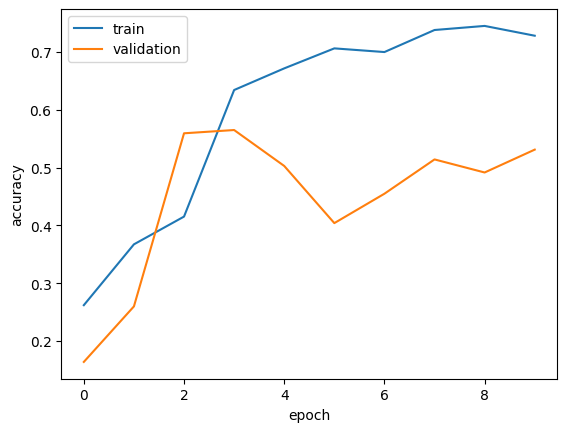

In [74]:
# 8. 시각화
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [75]:
# 9. 모델 저장 (.h5 = HDF5 파일 형식)
model.save('model_loan.h5')

# 저장한 모델을 다시 불러와서 새 기술명으로 예측해보기
# (새 문장도 학습 때와 똑같이: 명사 추출 → 번호 변환 → 패딩)
from tensorflow.keras.models import load_model
loaded_model = load_model('model_loan.h5')

new_text = 'AI 기반 감염관리 모니터링 시스템 개발'
new_nouns = ' '.join([n for n in okt.nouns(new_text) if len(n) > 1])
new_seq = tokenizer.texts_to_sequences([new_nouns])
new_pad = pad_sequences(new_seq, maxlen=max_len, padding='post')
print(new_text, '→ 승인 확률:', round(float(loaded_model.predict(new_pad)[0][0]), 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
AI 기반 감염관리 모니터링 시스템 개발 → 승인 확률: 0.99


In [77]:
from google.colab import files

files.download('model_loan.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

- 업력(2번, p=0.84), 평가등급(3번, p=0.29), 기술명(6·7번) 모두 대출 승인 여부와 뚜렷한 관계가 없음
- **승인을 잘 맞히는 변수** - 대출금액
    - 거부 405건 중 404건이 대출금액 0인데, 이는 심사 결과로 정해지는 값이라 사전 예측에는 쓸 수 없음

- **승인된 건의 대출금 합계** - 기업은행에 절반 이상(51.6%) 몰려 있음
    - 기업은행 안에서는 의료영상 AI·건강기능식품·의료영상 장치에 고르게 나뉘어 있음

- **자본금**이 큰 승인 기업은 건강기능식품·치료·진단 기술이 중심.
- **감염**은 병원 운영 관리 어휘(모니터링·수술실·병상)와 가깝게 쓰임